# Intelligent Multi-Pattern Search and Document Analytics Engine

**DSA Project – Final Revised Notebook**

This notebook consolidates the revised implementation developed for the project: 20 Newsgroups dataset loading, preprocessing, inverted-index retrieval, Aho–Corasick multi-pattern search, token-based validation, ranked search, performance evaluation, analytics, and edge-case validation.

## 1. Imports

In [1]:
import re
import time
from collections import defaultdict, Counter, deque

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups

## 2. Dataset Loading

In [2]:
dataset = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

documents = dataset.data
labels = dataset.target
target_names = dataset.target_names

print("Dataset loaded successfully!")
print("Total documents:", len(documents))
print("Number of categories:", len(target_names))

Dataset loaded successfully!
Total documents: 11314
Number of categories: 20


## 3. Text Preprocessing

In [3]:
def tokenize(text):
    text = text.lower()
    return re.findall(r"\b[a-zA-Z0-9]+\b", text)

sample_text = "Machine Learning is Amazing!"
print("Original text:", sample_text)
print("Tokenized text:", tokenize(sample_text))

Original text: Machine Learning is Amazing!
Tokenized text: ['machine', 'learning', 'is', 'amazing']


## 4. Dataset Analytics

In [4]:
category_counts = Counter(labels)
category_distribution = pd.DataFrame({
    "Category": [target_names[i] for i in category_counts],
    "Document_Count": list(category_counts.values())
}).sort_values("Document_Count", ascending=False).reset_index(drop=True)

document_lengths = [len(document) for document in documents]

dataset_summary = pd.DataFrame({
    "Metric": [
        "Total Documents", "Number of Categories",
        "Minimum Document Length", "Maximum Document Length",
        "Average Document Length"
    ],
    "Value": [
        len(documents), len(target_names), min(document_lengths),
        max(document_lengths), round(sum(document_lengths) / len(document_lengths), 2)
    ]
})

display(dataset_summary)
display(category_distribution)

,Metric,Value
0,Total Documents,11314.00
1,Number of Categories,20.00
2,Minimum Document Length,0.00
3,Maximum Document Length,74878.00
4,Average Document Length,1218.14


,Category,Document_Count
0,rec.sport.hockey,600
1,soc.religion.christian,599
2,rec.motorcycles,598
3,rec.sport.baseball,597
4,sci.crypt,595
5,rec.autos,594
6,sci.med,594
7,comp.windows.x,593
8,sci.space,593
9,comp.os.ms-windows.misc,591


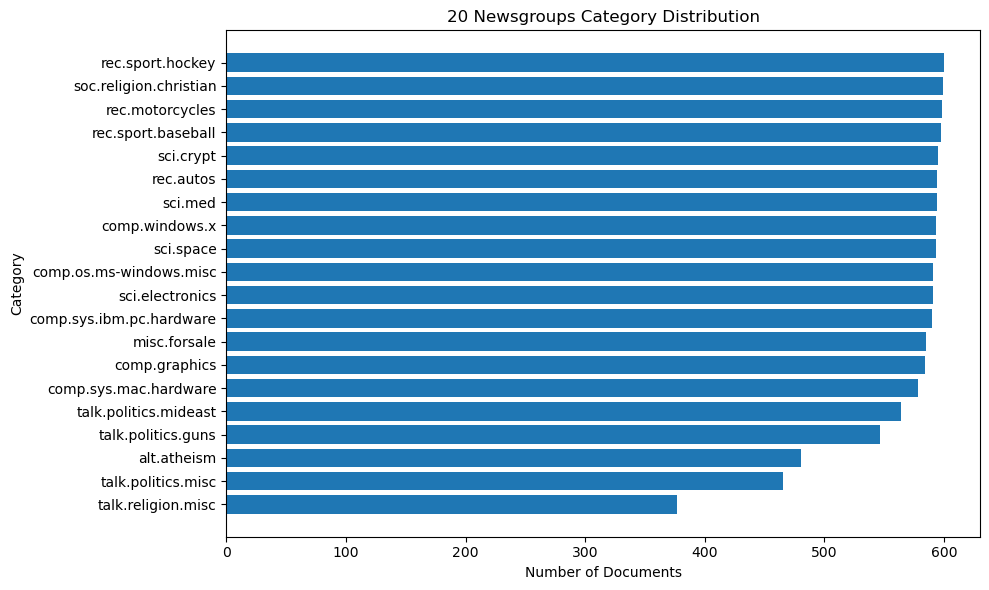

In [5]:
plt.figure(figsize=(10, 6))
plt.barh(category_distribution["Category"], category_distribution["Document_Count"])
plt.xlabel("Number of Documents")
plt.ylabel("Category")
plt.title("20 Newsgroups Category Distribution")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(document_lengths, bins=50)
plt.xlabel("Document Length (characters)")
plt.ylabel("Number of Documents")
plt.title("Document Length Distribution")
plt.tight_layout()
plt.show()

## 5. Inverted Index Construction

In [ ]:
def build_inverted_index(documents):
    inverted_index = defaultdict(set)
    for doc_id, document in enumerate(documents):
        tokens = tokenize(document)
        for token in set(tokens):
            inverted_index[token].add(doc_id)
    return dict(inverted_index)

start = time.perf_counter()
inverted_index = build_inverted_index(documents)
index_build_time = time.perf_counter() - start

print("Unique terms in inverted index:", len(inverted_index))
print("Index construction time: {:.6f} seconds".format(index_build_time))

## 6. Inverted Index AND Search

In [ ]:
def search_documents(query, inverted_index):
    query_terms = tokenize(query)
    if not query_terms:
        return set()

    query_terms = list(dict.fromkeys(query_terms))
    for term in query_terms:
        if term not in inverted_index:
            return set()

    result = inverted_index[query_terms[0]].copy()
    for term in query_terms[1:]:
        result &= inverted_index[term]
    return result

In [ ]:
computer_results = search_documents("computer", inverted_index)
computer_science_results = search_documents("computer science", inverted_index)

print('Documents containing "computer":', len(computer_results))
print('Documents containing both "computer" and "science":', len(computer_science_results))

## 7. Aho–Corasick Algorithm

In [ ]:
class AhoCorasick:
    def __init__(self):
        self.goto = [{}]
        self.fail = [0]
        self.output = [[]]

    def add_pattern(self, pattern):
        node = 0
        for char in pattern:
            if char not in self.goto[node]:
                self.goto[node][char] = len(self.goto)
                self.goto.append({})
                self.fail.append(0)
                self.output.append([])
            node = self.goto[node][char]
        self.output[node].append(pattern)

    def build_failure_links(self):
        queue = deque()
        for char, next_node in self.goto[0].items():
            self.fail[next_node] = 0
            queue.append(next_node)

        while queue:
            current = queue.popleft()
            for char, next_node in self.goto[current].items():
                queue.append(next_node)
                failure_node = self.fail[current]
                while failure_node != 0 and char not in self.goto[failure_node]:
                    failure_node = self.fail[failure_node]
                if char in self.goto[failure_node]:
                    self.fail[next_node] = self.goto[failure_node][char]
                else:
                    self.fail[next_node] = 0
                self.output[next_node].extend(self.output[self.fail[next_node]])

    def search(self, text):
        text = text.lower()
        node = 0
        found_patterns = []
        for char in text:
            while node != 0 and char not in self.goto[node]:
                node = self.fail[node]
            if char in self.goto[node]:
                node = self.goto[node][char]
            else:
                node = 0
            if self.output[node]:
                found_patterns.extend(self.output[node])
        return found_patterns

In [ ]:
test_patterns = ["he", "she", "his", "hers"]
ac_test = AhoCorasick()
for pattern in test_patterns:
    ac_test.add_pattern(pattern)
ac_test.build_failure_links()
print("Aho–Corasick test matches:", ac_test.search("ushers"))

## 8. Multi-Pattern Search

In [ ]:
def search_multiple_patterns(documents, patterns):
    ac = AhoCorasick()
    for pattern in patterns:
        ac.add_pattern(pattern.lower())
    ac.build_failure_links()

    results = defaultdict(set)
    for doc_id, document in enumerate(documents):
        matches = ac.search(document)
        for pattern in matches:
            results[doc_id].add(pattern)
    return dict(results)

def aho_corasick_or_search(documents, patterns):
    results = search_multiple_patterns(documents, patterns)
    return set(results.keys())

def aho_corasick_and_search(documents, patterns):
    patterns = [pattern.lower() for pattern in patterns]
    results = search_multiple_patterns(documents, patterns)
    required_patterns = set(patterns)
    return {doc_id for doc_id, matched in results.items() if required_patterns.issubset(matched)}

In [ ]:
patterns = ["computer", "science"]
ac_or_results = aho_corasick_or_search(documents, patterns)
ac_and_results = aho_corasick_and_search(documents, patterns)
print("Aho–Corasick OR results:", len(ac_or_results))
print("Aho–Corasick substring AND results:", len(ac_and_results))

## 9. Token-Based Aho–Corasick Search

In [ ]:
def search_multiple_patterns_token_based(documents, patterns):
    patterns = [pattern.lower() for pattern in patterns]
    ac = AhoCorasick()
    for pattern in patterns:
        ac.add_pattern(pattern)
    ac.build_failure_links()

    results = defaultdict(set)
    for doc_id, document in enumerate(documents):
        tokens = tokenize(document)
        normalized_text = " ".join(tokens)
        matches = ac.search(normalized_text)
        matched_patterns = set()
        token_set = set(tokens)
        for pattern in matches:
            if pattern in token_set:
                matched_patterns.add(pattern)
        if matched_patterns:
            results[doc_id] = matched_patterns
    return dict(results)

def token_based_aho_corasick_and_search(documents, patterns):
    patterns = [pattern.lower() for pattern in patterns]
    results = search_multiple_patterns_token_based(documents, patterns)
    required_patterns = set(patterns)
    return {doc_id for doc_id, matched in results.items() if required_patterns.issubset(matched)}

token_ac_and_results = token_based_aho_corasick_and_search(documents, patterns)
print("Token-based Aho–Corasick AND results:", len(token_ac_and_results))

## 10. Ranked Search

In [ ]:
def calculate_term_frequency(tokens):
    return Counter(tokens)

def ranked_and_search(query, documents, inverted_index):
    query_terms = tokenize(query)
    if not query_terms:
        return []
    query_terms = list(dict.fromkeys(query_terms))
    matching_documents = search_documents(query, inverted_index)
    ranked_results = []

    for doc_id in matching_documents:
        term_frequencies = calculate_term_frequency(tokenize(documents[doc_id]))
        score = sum(term_frequencies.get(term, 0) for term in query_terms)
        ranked_results.append({"Document_ID": doc_id, "Score": score})

    ranked_results.sort(key=lambda x: x["Score"], reverse=True)
    return ranked_results

In [ ]:
ranked_results = ranked_and_search("computer science", documents, inverted_index)
ranked_results_df = pd.DataFrame(ranked_results)
if not ranked_results_df.empty:
    ranked_results_df["Category"] = ranked_results_df["Document_ID"].apply(lambda doc_id: target_names[labels[doc_id]])
    display(ranked_results_df.head(10))

    plt.figure(figsize=(10, 6))
    top_10 = ranked_results_df.head(10)
    plt.bar(top_10["Document_ID"].astype(str), top_10["Score"])
    plt.xlabel("Document ID")
    plt.ylabel("Ranking Score")
    plt.title("Top 10 Ranked Documents")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 11. Search Result Comparison

In [ ]:
search_comparison = pd.DataFrame({
    "Search Method": [
        "Inverted Index - Single Term",
        "Inverted Index - AND",
        "Aho–Corasick - Substring AND",
        "Aho–Corasick - Token AND"
    ],
    "Documents": [
        len(computer_results), len(computer_science_results),
        len(ac_and_results), len(token_ac_and_results)
    ]
})
display(search_comparison)

plt.figure(figsize=(10, 5))
plt.bar(search_comparison["Search Method"], search_comparison["Documents"])
plt.ylabel("Number of Matching Documents")
plt.title("Search Result Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 12. Performance Evaluation

In [ ]:
def build_aho_corasick(patterns):
    ac = AhoCorasick()
    for pattern in patterns:
        ac.add_pattern(pattern.lower())
    ac.build_failure_links()
    return ac

def search_documents_with_automaton(documents, ac):
    results = defaultdict(set)
    for doc_id, document in enumerate(documents):
        matches = ac.search(document)
        for pattern in matches:
            results[doc_id].add(pattern)
    return dict(results)

In [ ]:
patterns = ["computer", "science"]

start = time.perf_counter()
benchmark_inverted_index = build_inverted_index(documents)
inverted_index_build_time = time.perf_counter() - start

start = time.perf_counter()
benchmark_ac = build_aho_corasick(patterns)
aho_corasick_build_time = time.perf_counter() - start

start = time.perf_counter()
benchmark_index_results = search_documents("computer science", benchmark_inverted_index)
inverted_index_query_time = time.perf_counter() - start

start = time.perf_counter()
benchmark_ac_results = search_documents_with_automaton(documents, benchmark_ac)
aho_corasick_search_time = time.perf_counter() - start

start = time.perf_counter()
benchmark_ranked_results = ranked_and_search("computer science", documents, benchmark_inverted_index)
ranked_search_time = time.perf_counter() - start

performance_summary = pd.DataFrame({
    "Operation": [
        "Inverted Index Build", "Aho–Corasick Build",
        "Inverted Index Query", "Aho–Corasick Search", "Ranked Search"
    ],
    "Time_Seconds": [
        inverted_index_build_time, aho_corasick_build_time,
        inverted_index_query_time, aho_corasick_search_time, ranked_search_time
    ]
})
performance_summary["Time_Milliseconds"] = performance_summary["Time_Seconds"] * 1000
display(performance_summary)

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(performance_summary["Operation"], performance_summary["Time_Milliseconds"])
plt.ylabel("Time (milliseconds)")
plt.title("Algorithm Performance Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Performance interpretation

The benchmark measures construction and search separately. The values are experimental measurements for the current machine and implementation; they should not be treated as universal speed claims. The inverted index is designed for repeated term lookup after construction, while Aho–Corasick is designed for simultaneous multi-pattern detection.

## 13. Validation and Edge Cases

In [ ]:
validation_results = []
def add_validation(name, passed, details):
    validation_results.append({"Test": name, "Passed": bool(passed), "Details": details})

# Normal query
normal_result = search_documents("computer", inverted_index)
add_validation("Normal query", len(normal_result) > 0, f"{len(normal_result)} documents returned")

# Case-insensitive search
case_lower = search_documents("computer", inverted_index)
case_upper = search_documents("COMPUTER", inverted_index)
case_mixed = search_documents("Computer", inverted_index)
add_validation("Case-insensitive search", case_lower == case_upper == case_mixed, "All case variants matched")

# Punctuation handling
punctuation_results = [
    search_documents("computer!", inverted_index),
    search_documents("computer,", inverted_index),
    search_documents('"computer"', inverted_index),
    search_documents("computer.", inverted_index)
]
add_validation("Punctuation handling", all(r == case_lower for r in punctuation_results), "Punctuation variants matched")

# Repeated terms
repeated = search_documents("computer computer science", inverted_index)
add_validation("Repeated query terms", repeated == computer_science_results, "Repeated terms do not change the result set")

# Nonexistent and empty queries
nonexistent = search_documents("termthatdoesnotexist123", inverted_index)
add_validation("Nonexistent term", len(nonexistent) == 0, "Zero documents returned")
empty_query = search_documents("", inverted_index)
add_validation("Empty query", len(empty_query) == 0, "Zero documents returned")

# AND set intersection
single_computer = search_documents("computer", inverted_index)
single_science = search_documents("science", inverted_index)
add_validation("AND set intersection", computer_science_results == (single_computer & single_science), "Posting-list intersection verified")

# Ranked result consistency and ordering
ranked_ids = {item["Document_ID"] for item in ranked_results}
scores = [item["Score"] for item in ranked_results]
add_validation("Ranked search preserves matching set", ranked_ids == computer_science_results, "Ranking changes order, not membership")
add_validation("Ranking order", scores == sorted(scores, reverse=True), "Scores are descending")

# Cross-algorithm validation
add_validation("Cross-algorithm consistency", token_ac_and_results == computer_science_results, f"Inverted Index={len(computer_science_results)}, Token AC={len(token_ac_and_results)}")

validation_df = pd.DataFrame(validation_results)
display(validation_df)
print(f"Validation passed: {validation_df['Passed'].sum()} / {len(validation_df)}")

## 14. Cross-Algorithm Result Analysis

In [ ]:
common_documents = computer_science_results & token_ac_and_results
only_inverted_index = computer_science_results - token_ac_and_results
only_token_ac = token_ac_and_results - computer_science_results

cross_algorithm_summary = pd.DataFrame({
    "Metric": [
        "Inverted Index AND", "Token-Based Aho–Corasick AND",
        "Common Documents", "Only Inverted Index",
        "Only Token-Based Aho–Corasick", "Substring Aho–Corasick AND"
    ],
    "Documents": [
        len(computer_science_results), len(token_ac_and_results),
        len(common_documents), len(only_inverted_index),
        len(only_token_ac), len(ac_and_results)
    ]
})
display(cross_algorithm_summary)

## 15. Final Project Metrics

In [ ]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Total Documents", "Number of Categories", "Unique Terms",
        "Average Document Length", "Computer Query Results",
        "Computer + Science AND Results", "Substring Aho–Corasick AND Results",
        "Token-Based Aho–Corasick AND Results", "Cross-Method Common Documents",
        "Validation Tests Passed"
    ],
    "Value": [
        len(documents), len(target_names), len(inverted_index),
        round(sum(document_lengths) / len(document_lengths), 2),
        len(computer_results), len(computer_science_results), len(ac_and_results),
        len(token_ac_and_results), len(common_documents), int(validation_df["Passed"].sum())
    ]
})
display(final_metrics)

## 16. Conclusion

The project implements a complete Python-based document search and analytics engine using inverted indexing, trie-based Aho–Corasick multi-pattern matching, token-aware validation, ranked retrieval, performance measurement, visualization, and automated edge-case testing.

**Workflow:** Dataset → Preprocessing → Index/Automaton Construction → Search → Ranking → Validation → Performance Evaluation → Analytics.

The numerical values and timing measurements used in the final report should come from the final execution of this notebook.